In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torchdyn.core import NeuralODE
from torchcfm.conditional_flow_matching import ExactOptimalTransportConditionalFlowMatcher
from matplotlib import animation
import numpy as np
import load_and_preprocess as lap
import train_and_eval_functions as taef
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
label = 'otfm_40mhz_sigma0p01_v1'
save_path = '/global/homes/m/mcohen54/ctfm_development/trained_models/trial_1'

batchSize = 512
numberOfEpochs = 20
patience = 5

pxpypz = True
p_train = 0.5
p_test = 0.25
plots_path = save_path+'/plots'

input_dim = 3
model_dim = 128
ff_dim = 128
num_heads = 4
num_layers = 4
n_mask_vals = 5 # 4 particle types + 1 padding

flowSigma = 0.01

trained = False
multiGPU = True


if not multiGPU:
    os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
datasets = lap.load_and_preprocess(
    p_train=p_train,
    p_test=p_test,
    plots_path=plots_path,
    pxpypz=pxpypz
    )

Extracting...
Loaded bkg
Loaded a4l
Loaded htaunu
Loaded htautau
Loaded lq
a4l: (55969, 19, 4)
htaunu: (760272, 19, 4)
htautau: (691283, 19, 4)
lq: (340544, 19, 4)
bkg_train: (2000000, 19, 4)
bkg_test: (1000000, 19, 4)
bkg_val: (1000000, 19, 4)


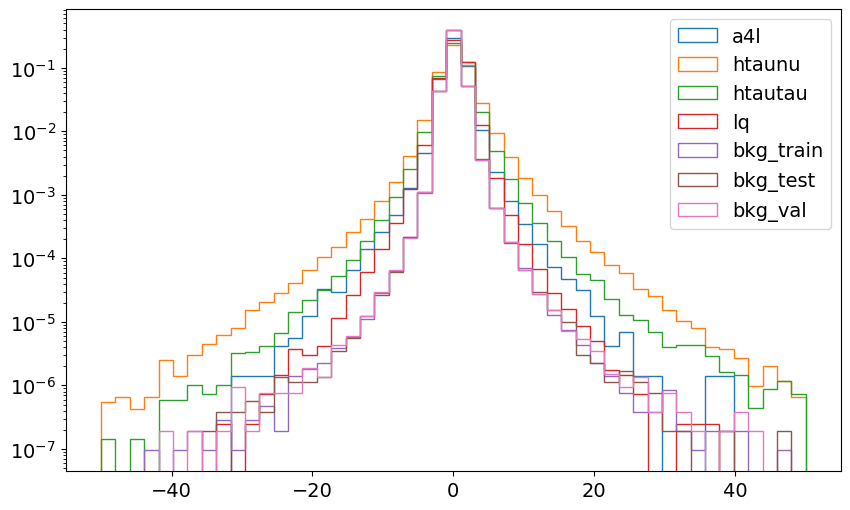

In [11]:
plt.figure(figsize=(10, 6))

for tag, data_dict in datasets.items():
    plt.hist(data_dict['data'][:,:,0].flatten()[data_dict['data'][:,:,-1].flatten()>0.5], bins=np.linspace(-50, 50), histtype='step', density=True, label=tag)

plt.legend()

plt.yscale('log')
plt.show()

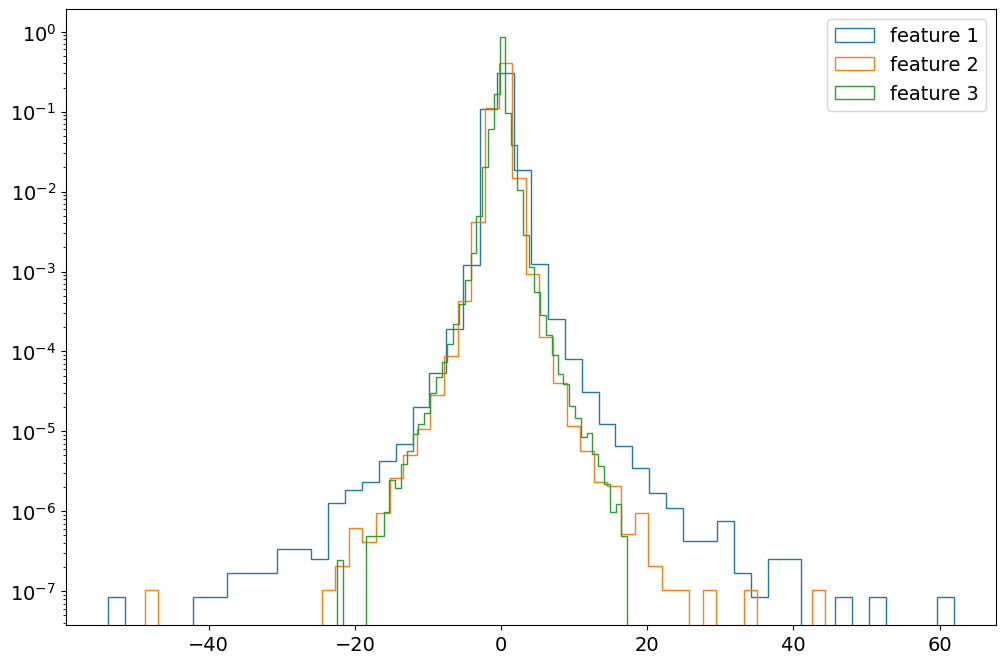

In [7]:
plt.figure(figsize=(12, 8))
plt.hist(datasets['bkg_train']['data'][:,:,0].flatten()[datasets['bkg_train']['data'][:,:,-1].flatten()>0.5], bins=50, histtype='step', density=True, label='feature 1')
plt.hist(datasets['bkg_train']['data'][:,:,1].flatten()[datasets['bkg_train']['data'][:,:,-1].flatten()>0.5], bins=50, histtype='step', density=True, label='feature 2')
plt.hist(datasets['bkg_train']['data'][:,:,2].flatten()[datasets['bkg_train']['data'][:,:,-1].flatten()>0.5], bins=50, histtype='step', density=True, label='feature 3')
plt.yscale('log')
plt.legend()
plt.show()